# KPI

항만 운영 KPI를 설정할때,
크게 3가지 정도로 나눌 수 있음.

1. 얼마나 많이 처리했는가.        : 처리량(Throughput)
2. 배가 얼마나 오래 머물렀는가.    : 체류시간(Dwell Time)
3. 한꺼번에 얼마나 몰렸는가.       : 혼잡도(Congestion)

- 대표적으로 이렇게 본다!

In [28]:
from cProfile import label

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles

In [20]:

def get_data_file_path(filename) :
    BASE_DIR = './data'
    EXTENSION = '.csv'
    return f'{BASE_DIR}/{filename}{EXTENSION}'
cols = [
    '항구명', '호출부호', '년도','항차', '계선장소시설코드', '계선장소명', '선박종류','입항일자','입항목적','출항예정일시'
]

df = pd.read_csv(get_data_file_path('수송통계'))

df.shape

(31, 15)

In [21]:
berth_cols = df.columns.drop(['년도','합계'])

sum_miss_match = df[berth_cols].sum(axis=1) !=df['합계'].sum()

print(f'합계 불일치 갯수 : {sum_miss_match}')

합계 불일치 갯수 : 0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9     True
10    True
11    True
12    True
13    True
14    True
15    True
16    True
17    True
18    True
19    True
20    True
21    True
22    True
23    True
24    True
25    True
26    True
27    True
28    True
29    True
30    True
dtype: bool


In [22]:
(df[berth_cols] ==0).sum()

자성대부두      2
신선대부두      1
감만부두       3
우암부두       6
감천한진       3
신감만부두      8
일반부두       0
신항1부두     12
신항2부두     13
신항3부두     15
신항4부두     16
신항5부두     17
다목적부두등    14
dtype: int64

In [23]:
df = df.set_index('년도')
df

,합계,자성대부두,신선대부두,감만부두,우암부두,감천한진,신감만부두,일반부두,신항1부두,신항2부두,신항3부두,신항4부두,신항5부두,다목적부두등
년도,,,,,,,,,,,,,,
1994,48140,0,0,0,0,0,0,48140,0,0,0,0,0,0
1995,59775,0,622,0,0,0,0,59153,0,0,0,0,0,0
1996,4809217,1673341,1302513,0,21171,0,0,1812192,0,0,0,0,0,0
1997,5246646,1757757,1413847,23,316902,11848,0,1746269,0,0,0,0,0,0
1998,5701360,1096650,1121949,891424,281571,348910,0,1960856,0,0,0,0,0,0
1999,6555803,995119,1160577,1458472,355761,449766,0,2136108,0,0,0,0,0,0
2000,7729508,1304180,1281914,1887418,342486,403174,0,2510336,0,0,0,0,0,0
2001,8073125,1272333,1319812,1922622,447704,432972,0,2677682,0,0,0,0,0,0
2002,9453858,1534639,1528424,2261533,502460,504269,481202,2641331,0,0,0,0,0,0


In [24]:
# 신항 북항 구분

# [c for c in berth_cols if c.startswith('신항')]

df['신항'] = df[['신항1부두','신항2부두','신항3부두','신항4부두','신항5부두']].sum(axis=1)
df['북항등'] = df['합계'] - df['신항']
df['신항비중'] = df['신항'] / df['합계'] * 100

In [25]:
df['증감률'] = df['합계'].pct_change()*100

df['증감률']

년도
1994            NaN
1995      24.169090
1996    7945.532413
1997       9.095639
1998       8.666756
1999      14.986652
2000      17.903299
2001       4.445522
2002      17.102832
2003      10.095138
2004      10.416537
2005       3.052013
2006       1.650243
2007      10.188222
2008       1.427646
2009     -11.067080
2010      18.325450
2011      13.549280
2012       6.031338
2013       3.754031
2014       5.638258
2015       4.203955
2016      -0.063861
2017       5.330856
2018       5.704712
2019       1.520724
2020      -0.763932
2021       4.042037
2022      -2.765487
2023       4.870484
2024       5.392318
Name: 증감률, dtype: float64

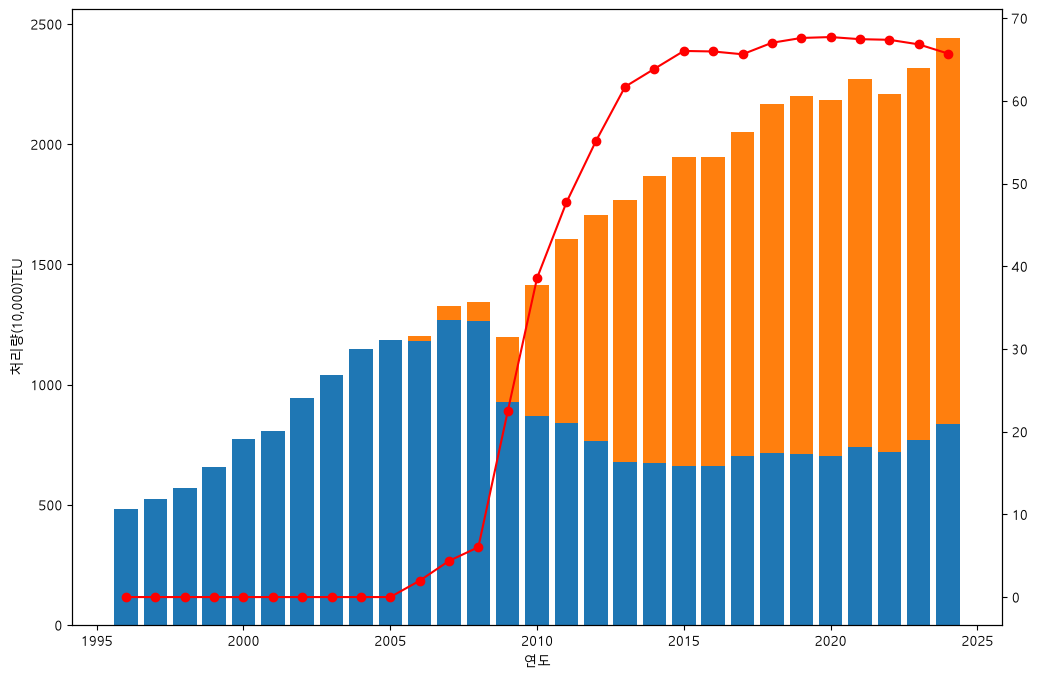

In [31]:
plot_df = df.loc[1996:]

# plt.rcParams['font.family'] = 'Malgun Gothic'

fig, ax = plt.subplots(figsize=(12,8))

ax.bar(
    plot_df.index,
    plot_df['북항등']/10_000,
    label='북항 등'
)
ax.bar(
    plot_df.index,
    plot_df['신항']/10_000,
    bottom=plot_df['북항등'] / 10000,
    label='북항 등'
)

ax.set_xlabel('연도')
ax.set_ylabel('처리량(10,000)TEU')

ax2 = ax.twinx()
ax2.plot(
    plot_df.index,
    plot_df['신항비중'],
    marker = 'o',
    label='신항구성비',
    color='red',
)

In [35]:
def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')

df = load_dataset('입출항집계정보')

cols=['선박종류명','총톤수','입항일시','출항일시']

df = df[cols].copy()

In [36]:
df

,선박종류명,총톤수,입항일시,출항일시
0,풀컨테이너선,18334.0,2019-10-17 14:00,2019-10-18 14:00
1,LPG 운반선,3345.0,2019-10-15 19:00,2019-10-16 10:00
2,일반화물선,2398.0,2019-10-14 06:00,2019-10-14 16:00
3,석유제품 운반선,200.0,2019-09-26 15:50,2019-10-08 05:35
4,세미(혼재)컨테이너선,13682.0,2019-06-26 20:00,2019-06-27 12:00
...,...,...,...,...
272899,기타 예선,19.0,2023-09-11 13:05,2023-09-19 15:25
272900,기타 예선,19.0,2023-11-03 08:37,2023-12-04 08:54
272901,기타 예선,19.0,2023-12-04 16:05,2023-12-04 16:06
272902,견인용예선,49.0,2023-12-27 08:55,2024-01-04 11:25


In [44]:
df['입항'] = pd.to_datetime(df['입항일시'], format='%Y-%m-%d %H:%M', errors='coerce')
df['출항'] = pd.to_datetime(df['출항일시'], format='%Y-%m-%d %H:%M', errors='coerce')

df['입항'].isna().sum()
df['출항'].isna().sum()

df['체류시간'] = (df['출항'] - df['입항']).dt.total_seconds()/3600

df


,선박종류명,총톤수,입항일시,출항일시,입항,출항,체류시간
0,풀컨테이너선,18334.0,2019-10-17 14:00,2019-10-18 14:00,2019-10-17 14:00:00,2019-10-18 14:00:00,24.000000
1,LPG 운반선,3345.0,2019-10-15 19:00,2019-10-16 10:00,2019-10-15 19:00:00,2019-10-16 10:00:00,15.000000
2,일반화물선,2398.0,2019-10-14 06:00,2019-10-14 16:00,2019-10-14 06:00:00,2019-10-14 16:00:00,10.000000
3,석유제품 운반선,200.0,2019-09-26 15:50,2019-10-08 05:35,2019-09-26 15:50:00,2019-10-08 05:35:00,277.750000
4,세미(혼재)컨테이너선,13682.0,2019-06-26 20:00,2019-06-27 12:00,2019-06-26 20:00:00,2019-06-27 12:00:00,16.000000
...,...,...,...,...,...,...,...
272899,기타 예선,19.0,2023-09-11 13:05,2023-09-19 15:25,2023-09-11 13:05:00,2023-09-19 15:25:00,194.333333
272900,기타 예선,19.0,2023-11-03 08:37,2023-12-04 08:54,2023-11-03 08:37:00,2023-12-04 08:54:00,744.283333
272901,기타 예선,19.0,2023-12-04 16:05,2023-12-04 16:06,2023-12-04 16:05:00,2023-12-04 16:06:00,0.016667
272902,견인용예선,49.0,2023-12-27 08:55,2024-01-04 11:25,2023-12-27 08:55:00,2024-01-04 11:25:00,194.500000


In [51]:
# 제외할것들 고르는 중
df['체류시간'].describe()[['mean','50%','min','max']].round(1)

mean       113.2
50%         20.9
min      -3363.0
max     626602.2
Name: 체류시간, dtype: float64

In [53]:

out_of_years = ~df['입항'].dt.year.between(2019,2024)


out_of_years.sum()

(df['체류시간']<0).sum()

(df['체류시간']==0).sum()

(df['체류시간']>720).sum()


time_cond = df['체류시간'].between(0.5,720)

valid = ~out_of_years & time_cond
dwell = df[valid].copy()

dwell

,선박종류명,총톤수,입항일시,출항일시,입항,출항,체류시간
0,풀컨테이너선,18334.0,2019-10-17 14:00,2019-10-18 14:00,2019-10-17 14:00:00,2019-10-18 14:00:00,24.000000
1,LPG 운반선,3345.0,2019-10-15 19:00,2019-10-16 10:00,2019-10-15 19:00:00,2019-10-16 10:00:00,15.000000
2,일반화물선,2398.0,2019-10-14 06:00,2019-10-14 16:00,2019-10-14 06:00:00,2019-10-14 16:00:00,10.000000
3,석유제품 운반선,200.0,2019-09-26 15:50,2019-10-08 05:35,2019-09-26 15:50:00,2019-10-08 05:35:00,277.750000
4,세미(혼재)컨테이너선,13682.0,2019-06-26 20:00,2019-06-27 12:00,2019-06-26 20:00:00,2019-06-27 12:00:00,16.000000
...,...,...,...,...,...,...,...
272897,견인용예선,49.0,2023-12-23 11:15,2023-12-27 06:45,2023-12-23 11:15:00,2023-12-27 06:45:00,91.500000
272898,기타 예선,19.0,2023-09-11 11:38,2023-09-11 12:37,2023-09-11 11:38:00,2023-09-11 12:37:00,0.983333
272899,기타 예선,19.0,2023-09-11 13:05,2023-09-19 15:25,2023-09-11 13:05:00,2023-09-19 15:25:00,194.333333
272902,견인용예선,49.0,2023-12-27 08:55,2024-01-04 11:25,2023-12-27 08:55:00,2024-01-04 11:25:00,194.500000


In [57]:
print(len(dwell), round(valid.mean()*100,1))

dwell.describe()

dwell['체류시간'].agg(['mean','median']).round(1)

#여기까지가 전처리!!!

259925 95.2


mean      50.9
median    21.2
Name: 체류시간, dtype: float64

In [62]:
# 선박종류에 따라 다른가, 정기선/비정기선 에 따라 다른가를 다시한번 확인 할것!

by_type = dwell.groupby('선박종류명')['체류시간'].agg(
    건수='count',
    중앙값='median',
    평균='mean',
    상위10=lambda x:x.quantile(0.9) # 익명함수!
).sort_values('건수',ascending=False)

by_type.head().round(1)

,건수,중앙값,평균,상위10
선박종류명,,,,
풀컨테이너선,78359,19.9,25.2,42.1
석유제품 운반선,62012,27.7,56.8,140.7
일반화물선,22212,17.5,44.4,104.6
견인용예선,18696,27.6,76.2,212.4
기타 예선,10939,23.8,74.9,218.5


In [63]:
yearly_median = dwell.groupby(
    dwell['입항'].dt.year
)['체류시간'].median().round(1)

yearly_median

입항
2019    18.6
2020    20.1
2021    23.5
2022    22.3
2023    20.9
2024    22.4
Name: 체류시간, dtype: float64

In [70]:
top_types = by_type.head().index
data = [dwell.loc[dwell['선박종류명'] == t,'체류시간'] for t in top_types ]

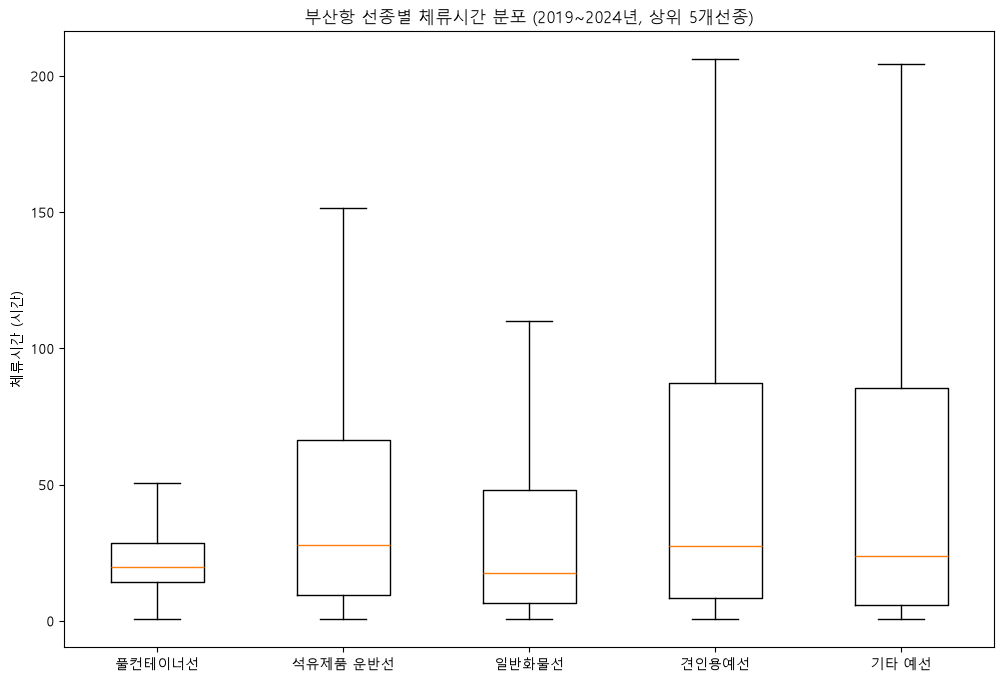

In [74]:

fig, ax = plt.subplots(figsize=(12,8))
fig = ax.boxplot(
    data,
    showfliers=False
)

ax.set_xticks(range(1,len(top_types)+1),top_types)
ax.set_ylabel('체류시간 (시간)')
ax.set_title('부산항 선종별 체류시간 분포 (2019~2024년, 상위 5개선종)')


plt.show()


동시체류수(척수)는 지금 이 순간에 항만 안에 몇척이 있었는가 를 시간순서대로 샌 값
**어느 시점**에 차가 몇대 있었나를 알 수 있음
기록해두면 체류선박척수를 구할 수 있다?
선박입출항을 이벤트라고 생각하고 이벤트가 만들어지는 시간 순서대로 정렬한다음 하나씩 누적해서 합산하는 방식으로 계산

특정기간 전년도의 12/31에 들어와서 1/1에 머물고있던 배가 있다고 한다면 입항기록이 빠지고 이후에 출항기록만 남는다. (관측 초기에는 실제보다 적게 나올 수 있다.)
체류량이 얼마정도 누적된 다음에 계산해보는 것이 보다 안전한 방법이다.

5/1~6/1 한달체류량을 볼때는 중간에 들어온건 계산이 안됨 퉁친다?


## 시간대별 동시체류수



In [96]:
# 풀컨테이너선, 2024년

con24 = dwell[(dwell['선박종류명'] == '풀컨테이너선')&(dwell['입항'].dt.year == 2024)&(dwell['출항'].dt.year == 2024)].copy()

len(con24)

in_con = pd.Series(1,index=con24['입항'])
out_con = pd.Series(-1,index=con24['출항'])

In [97]:
events = pd.concat(
    [in_con,out_con]
).sort_index()

events

2024-01-01 00:18:00    1
2024-01-01 00:42:00    1
2024-01-01 00:58:00    1
2024-01-01 01:00:00    1
2024-01-01 01:00:00    1
                      ..
2024-12-31 20:48:00   -1
2024-12-31 20:49:00   -1
2024-12-31 21:00:00   -1
2024-12-31 21:00:00   -1
2024-12-31 22:30:00   -1
Length: 25716, dtype: int64

In [98]:
#cumsum=cumulative sum 시간의 흐름에 따라서 변화량을 누적해서 합산
occupancy = events.groupby(level=0).sum().cumsum()

occupancy

2024-01-01 00:18:00    1
2024-01-01 00:42:00    2
2024-01-01 00:58:00    3
2024-01-01 01:00:00    5
2024-01-01 01:55:00    6
                      ..
2024-12-31 19:56:00    5
2024-12-31 20:48:00    4
2024-12-31 20:49:00    3
2024-12-31 21:00:00    1
2024-12-31 22:30:00    0
Length: 23787, dtype: int64

In [99]:
hourly_occupancy = occupancy.resample('h').last().ffill()

hourly_occupancy

2024-01-01 00:00:00    3.0
2024-01-01 01:00:00    6.0
2024-01-01 02:00:00    7.0
2024-01-01 03:00:00    7.0
2024-01-01 04:00:00    8.0
                      ... 
2024-12-31 18:00:00    7.0
2024-12-31 19:00:00    5.0
2024-12-31 20:00:00    3.0
2024-12-31 21:00:00    1.0
2024-12-31 22:00:00    0.0
Freq: h, Length: 8783, dtype: float64

In [100]:
hourly_occupancy.loc['2024-01-01':'2024-01-07'].mean()

np.float64(31.898809523809526)

In [101]:
stable = hourly_occupancy.loc['2024-02-01':'2024-12-31']

stable.groupby(stable.index.dayofweek).mean().round(1)

0    36.1
1    34.3
2    37.6
3    38.1
4    37.6
5    38.0
6    38.5
dtype: float64

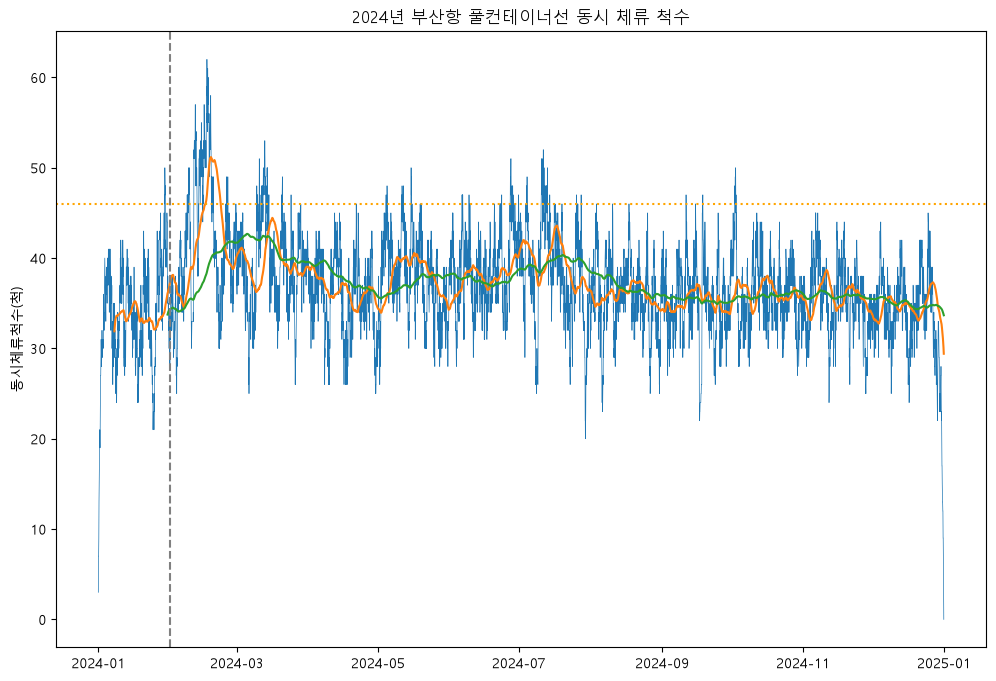

In [121]:
fig, ax = plt.subplots(figsize=(12,8))

ax.plot(hourly_occupancy.index, hourly_occupancy, linewidth=0.5, label='1시간단위')
ax.plot(hourly_occupancy.rolling(24*7).mean(), label='7일 이동평균')
ax.plot(hourly_occupancy.rolling(24*30).mean(), label='30일 이동평균')

ax.axvline(pd.Timestamp('2024-02-01'), color='gray', linestyle='--')
ax.axhline(stable.quantile(0.95),color='orange', linestyle=':')

ax.set_title('2024년 부산항 풀컨테이너선 동시 체류 척수')
ax.set_ylabel('동시체류척수(척)')

plt.show()



In [ ]:
# 선박관제정보로 시간대별 혼잡도 그래프로 그리기까지

